# Task 1: application inference from packet flows

Train and validation are merged into one labelled set of 330 flows. Models are compared with repeated stratified 5-fold CV on macro F1, with RFECV feature selection inside the CV, and the best one is refit on all labelled rows to predict the test set.

## Load and combine train + validation

In [7]:
import os

# clean up the earlier attempts
os.chdir("/content")
!rm -rf /content/dataset /content/application-inference-packet-flows-public

# 1) clone the WHOLE repo here
REPO_ROOT = "/content/application-inference-packet-flows-public"
!git clone https://github.com/temilash/application-inference-packet-flows-public.git {REPO_ROOT}

# 2) then move into the data folder INSIDE it
DATA_DIR = REPO_ROOT + "/dataset/task1_static"
os.chdir(DATA_DIR)
print("Now in:", os.getcwd())
!ls -lh
!nvidia-smi

Cloning into '/content/application-inference-packet-flows-public'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 45 (delta 9), reused 34 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 538.48 KiB | 7.69 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Now in: /content/application-inference-packet-flows-public/dataset/task1_static
total 100K
-rw-r--r-- 1 root root 1.1K Oct  7 12:48 metadata.json
-rw-r--r-- 1 root root 1.6K Oct  7 12:48 sample_submission.csv
-rw-r--r-- 1 root root  15K Oct  7 12:48 test_features.csv
-rw-r--r-- 1 root root  45K Oct  7 12:48 train_features.csv
-rw-r--r-- 1 root root 4.5K Oct  7 12:48 train_labels.csv
-rw-r--r-- 1 root root  16K Oct  7 12:48 validation_features.csv
-rw-r--r-- 1 root root 1.6K Oct  7 12:48 validation_labels.csv
Wed Oct  7 12:48:43 2026       
+------------------------------------------------------------------------------

In [10]:
import numpy as np
import pandas as pd
import lightgbm as lgb

# Combine train + validation into one labelled set; the validation split
# is no longer held out, model choice is made with stratified K-fold instead.
train_all = pd.concat([
    pd.read_csv('train_features.csv').merge(pd.read_csv('train_labels.csv'), on='flow_id', validate='one_to_one'),
    pd.read_csv('validation_features.csv').merge(pd.read_csv('validation_labels.csv'), on='flow_id', validate='one_to_one'),
], ignore_index=True)

test_features = pd.read_csv('test_features.csv')

print("Combined labelled rows:", len(train_all))
print(train_all['app'].value_counts())
print("Test rows:", len(test_features))

Combined labelled rows: 330
app
google       131
x             73
youtube       55
mozilla       41
instagram     19
facebook      11
Name: count, dtype: int64
Test rows: 81


## Feature engineering
The same features are applied to train + validation and to test. `server_port` (constant 443), `split` and `start_rel` are dropped.

In [11]:
def add_context_features(dataframe, neighbour_window=2.0):
    # Describes the other flows that start close in time to each flow. Uses only feature
    # columns, never labels, so it must be run on train + validation + test together:
    # a test flow's neighbours are mostly labelled flows and vice versa.
    start = dataframe['start_rel'].to_numpy()
    time_gap = np.abs(start[:, None] - start[None, :])
    np.fill_diagonal(time_gap, np.inf)  # a flow is never its own neighbour

    # Other flows starting within ±neighbour_window seconds (statistics are NaN if there are none)
    is_neighbour = time_gap <= neighbour_window
    neighbour_count = is_neighbour.sum(axis=1)
    dataframe['neighbour_count'] = neighbour_count

    with np.errstate(invalid='ignore', divide='ignore'):
        for column in ['duration', 'mean_pkt_size_down', 'mean_pkt_size_up', 'std_pkt_size_down', 'max_iat']:
            dataframe[f'neighbour_mean_{column}'] = (is_neighbour @ dataframe[column].to_numpy()) / neighbour_count
        dataframe['neighbour_udp_share'] = (is_neighbour @ (dataframe['transport'].to_numpy() == 1)) / neighbour_count

    # Largest download among the neighbours, e.g. a video stream running alongside
    bytes_down = dataframe['bytes_down'].to_numpy()
    dataframe['neighbour_max_bytes_down'] = np.where(
        neighbour_count > 0, np.where(is_neighbour, bytes_down[None, :], -np.inf).max(axis=1), np.nan
    )

    # The single closest flow in time, wherever it is
    nearest = time_gap.argmin(axis=1)
    dataframe['nearest_gap'] = time_gap[np.arange(len(start)), nearest]
    dataframe['nearest_duration'] = dataframe['duration'].to_numpy()[nearest]
    dataframe['nearest_mean_pkt_size_down'] = dataframe['mean_pkt_size_down'].to_numpy()[nearest]
    dataframe['nearest_same_transport'] = (dataframe['transport'].to_numpy()[nearest] == dataframe['transport'].to_numpy()).astype(int)

    # How much this flow looks like its neighbours
    dataframe['pkt_size_down_vs_neighbours'] = dataframe['mean_pkt_size_down'] - dataframe['neighbour_mean_mean_pkt_size_down']
    dataframe['duration_vs_neighbours'] = dataframe['duration'] - dataframe['neighbour_mean_duration']

    return dataframe


def add_features(dataframe):
    dataframe = dataframe.copy()

    dataframe['transport'] = (
        dataframe['transport'].fillna('unknown').astype(str).str.strip().str.lower()
        .map({'tcp': 0, 'udp': 1, 'unknown': 2})
    )
    if dataframe['transport'].isna().any():
        raise ValueError("Unexpected transport values found")

    dataframe['packet_count_diff'] = dataframe.packet_count_up - dataframe.packet_count_down
    dataframe['byte_diff'] = dataframe.bytes_up - dataframe.bytes_down
    dataframe['density_up'] = dataframe.bytes_up / dataframe.duration
    dataframe['density_down'] = dataframe.bytes_down / dataframe.duration
    dataframe['density_ratio'] = dataframe['density_up'] / dataframe['density_down']
    dataframe['average_packet_ratio'] = dataframe.mean_pkt_size_up / dataframe.mean_pkt_size_down
    dataframe['total_bytes'] = dataframe.bytes_up + dataframe.bytes_down
    dataframe['total_packet_count'] = dataframe.packet_count_up + dataframe.packet_count_down
    dataframe['upload_ratio'] = dataframe.bytes_up / dataframe.total_bytes
    dataframe['flow_density'] = dataframe.total_bytes / dataframe.duration
    dataframe['packet_rate'] = dataframe.total_packet_count / dataframe.duration
    dataframe['burst_rate'] = dataframe.burst_count / dataframe.duration
    dataframe['pkt_size_cv_up'] = dataframe.std_pkt_size_up / dataframe.mean_pkt_size_up
    dataframe['pkt_size_cv_down'] = dataframe.std_pkt_size_down / dataframe.mean_pkt_size_down
    dataframe['iat_cv'] = dataframe['std_iat'] / dataframe['mean_iat']
    dataframe['iat_zscore_of_max'] = (dataframe['max_iat'] - dataframe['mean_iat']) / dataframe['std_iat']

    dataframe = add_context_features(dataframe)

    dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)
    return dataframe


# server_port is constant (443), split/start_rel describe the capture rather than the flow.
# start_rel is still used above to build the context features, just not fed to the model directly.
drop_columns = ['flow_id', 'split', 'server_port', 'start_rel', 'app']

# Engineer features on all flows at once so the context features see every neighbour,
# then split back into labelled rows and test rows (row order is preserved)
all_flows_fe = add_features(pd.concat([train_all, test_features], ignore_index=True))
train_all_fe = all_flows_fe[all_flows_fe['app'].notna()].reset_index(drop=True)
test_fe = all_flows_fe[all_flows_fe['app'].isna()].reset_index(drop=True)

X_all = train_all_fe.drop(columns=drop_columns)
y_all = train_all_fe['app']
X_test = test_fe.drop(columns=drop_columns)

assert X_all.columns.tolist() == X_test.columns.tolist()
assert test_fe['flow_id'].tolist() == test_features['flow_id'].tolist()
print("Feature count:", X_all.shape[1])

Feature count: 47


## Candidate models
Each model is tried with all features and with RFECV in front of it, so cross-validation decides whether removing features helps.

In [12]:
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_validate
from sklearn.feature_selection import RFECV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

# objective is left out: LightGBM picks multiclass or binary itself (the two-step specialist is binary)
lgb_params = dict(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=8,
    min_child_samples=3,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    random_state=2026,
    verbosity=-1,
    n_jobs=1,  # parallelism happens across CV folds instead; nested threading is ~10x slower here
)


def make_rfecv():
    # Drops the weakest feature one at a time and keeps the count with the best inner-CV macro F1
    return RFECV(
        estimator=lgb.LGBMClassifier(**{**lgb_params, 'n_estimators': 150}, class_weight='balanced'),
        step=0.1,
        min_features_to_select=5,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=2026),
        scoring='f1_macro',
    )


def make_models():
    lgbm = lgb.LGBMClassifier(**lgb_params,device="gpu" ,class_weight='balanced')
    random_forest = make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(n_estimators=500, class_weight='balanced_subsample', random_state=2026),
    )
    extra_trees = make_pipeline(
        SimpleImputer(strategy='median'),
        ExtraTreesClassifier(n_estimators=500, class_weight='balanced', random_state=2026),
    )
    soft_vote = VotingClassifier(
        estimators=[('lgbm', lgbm), ('rf', random_forest), ('et', extra_trees)],
        voting='soft',
    )
    return {'lgbm': lgbm, 'random_forest': random_forest, 'extra_trees': extra_trees, 'soft_vote': soft_vote}


# Each model is tried with all features and with RFECV in front of it. RFECV sits inside
# the pipeline so feature selection is redone in every CV fold and never sees that fold's
# held-out rows, otherwise the CV score would be optimistic.
candidate_models = dict(make_models())
for name, model in make_models().items():
    candidate_models[f'rfecv + {name}'] = make_pipeline(make_rfecv(), model)

## Two-step classifier
Step 1 predicts the group (google + youtube together, every other app alone), step 2 a google-vs-youtube specialist decides inside that group. Added as two more candidates, with and without RFECV, so CV compares it against the single-step models.

In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone


class TwoStepClassifier(ClassifierMixin, BaseEstimator):
    """Step 1 predicts a group of apps, step 2 a specialist picks the app inside a multi-app group.

    Apps not listed in `groups` form a group on their own. Probabilities are combined softly,
    P(app) = P(group) * P(app | group), so an unsure step 1 does not lock in a wrong group.
    """

    def __init__(self, group_model, specialist_model, groups):
        self.group_model = group_model
        self.specialist_model = specialist_model
        self.groups = groups

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        app_to_group = {app: '+'.join(group) for group in self.groups for app in group}
        y_group = np.array([app_to_group.get(app, app) for app in y])

        self.group_model_ = clone(self.group_model).fit(X, y_group)

        # Each specialist only sees the flows of its own group
        self.specialists_ = {}
        for group in self.groups:
            in_group = np.isin(y, group)
            self.specialists_['+'.join(group)] = clone(self.specialist_model).fit(X[in_group], y[in_group])
        return self

    def predict_proba(self, X):
        class_index = {app: i for i, app in enumerate(self.classes_)}
        group_proba = self.group_model_.predict_proba(X)
        proba = np.zeros((len(X), len(self.classes_)))

        for j, group in enumerate(self.group_model_.classes_):
            if group in self.specialists_:
                specialist = self.specialists_[group]
                specialist_proba = specialist.predict_proba(X)
                for k, app in enumerate(specialist.classes_):
                    proba[:, class_index[app]] += group_proba[:, j] * specialist_proba[:, k]
            else:
                proba[:, class_index[group]] += group_proba[:, j]
        return proba

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


# google <-> youtube is the largest confusion (24 of 53 out-of-fold errors), so they share
# a group and get a dedicated specialist; every other app is a group on its own
app_groups = [['google', 'youtube']]

candidate_models['two_step soft_vote'] = TwoStepClassifier(
    group_model=make_models()['soft_vote'],
    specialist_model=make_models()['soft_vote'],
    groups=app_groups,
)
candidate_models['rfecv + two_step soft_vote'] = make_pipeline(
    make_rfecv(),
    TwoStepClassifier(
        group_model=make_models()['soft_vote'],
        specialist_model=make_models()['soft_vote'],
        groups=app_groups,
    ),
)
print(list(candidate_models))

['lgbm', 'random_forest', 'extra_trees', 'soft_vote', 'rfecv + lgbm', 'rfecv + random_forest', 'rfecv + extra_trees', 'rfecv + soft_vote', 'two_step soft_vote', 'rfecv + two_step soft_vote']


## Compare candidates with repeated stratified K-fold
Takes about 5 minutes on 12 cores.

In [14]:
# 5 folds x 3 repeats: every fold keeps the class mix, repeats smooth out split-to-split noise
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2026)

cv_rows = []
for name, model in candidate_models.items():
    scores = cross_validate(model, X_all, y_all, cv=cv, scoring=['f1_macro', 'accuracy'], n_jobs=-1)
    cv_rows.append({
        'model': name,
        'macro_f1_mean': scores['test_f1_macro'].mean(),
        'macro_f1_std': scores['test_f1_macro'].std(),
        'accuracy_mean': scores['test_accuracy'].mean(),
    })
    print(f"{name:25s} macro F1 = {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")

cv_results = pd.DataFrame(cv_rows).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
cv_results

lgbm                      macro F1 = 0.7713 ± 0.0755
random_forest             macro F1 = 0.7496 ± 0.0815
extra_trees               macro F1 = 0.7557 ± 0.0860
soft_vote                 macro F1 = 0.7817 ± 0.0690
rfecv + lgbm              macro F1 = 0.7537 ± 0.0870
rfecv + random_forest     macro F1 = 0.7314 ± 0.0874
rfecv + extra_trees       macro F1 = 0.7472 ± 0.0778
rfecv + soft_vote         macro F1 = 0.7862 ± 0.0660
two_step soft_vote        macro F1 = 0.7734 ± 0.0715
rfecv + two_step soft_vote macro F1 = 0.7544 ± 0.0828


,model,macro_f1_mean,macro_f1_std,accuracy_mean
0,rfecv + soft_vote,0.786183,0.066024,0.839394
1,soft_vote,0.781700,0.068972,0.841414
2,two_step soft_vote,0.773426,0.071507,0.834343
3,lgbm,0.771318,0.075538,0.834343
4,extra_trees,0.755671,0.085953,0.827273
5,rfecv + two_step soft_vote,0.754394,0.082824,0.829293
6,rfecv + lgbm,0.753666,0.086965,0.822222
7,random_forest,0.749625,0.081471,0.816162
8,rfecv + extra_trees,0.747219,0.077834,0.821212
9,rfecv + random_forest,0.731405,0.087389,0.811111


## Per-class out-of-fold results for the best model

Best model by CV macro F1: rfecv + soft_vote
              precision    recall  f1-score   support

    facebook      1.000     0.455     0.625        11
      google      0.800     0.885     0.841       131
   instagram      0.765     0.684     0.722        19
     mozilla      0.902     0.902     0.902        41
           x      0.859     0.918     0.887        73
     youtube      0.841     0.673     0.747        55

    accuracy                          0.833       330
   macro avg      0.861     0.753     0.788       330
weighted avg      0.837     0.833     0.829       330



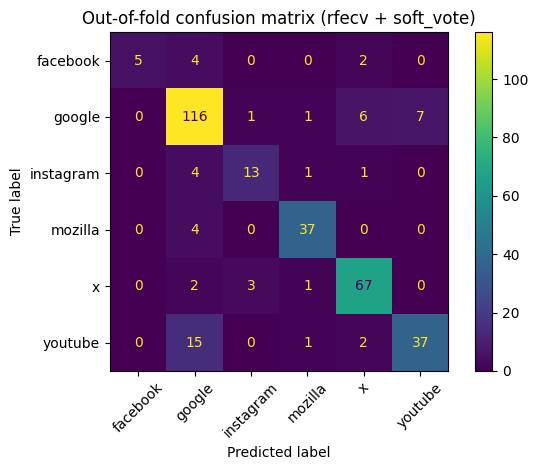

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = cv_results.loc[0, 'model']
best_model = candidate_models[best_model_name]
print("Best model by CV macro F1:", best_model_name)

# Out-of-fold predictions give a per-class view of where the best model fails
oof_predictions = cross_val_predict(
    best_model, X_all, y_all,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=2026),
    n_jobs=-1,
)
print(classification_report(y_all, oof_predictions, digits=3))

ConfusionMatrixDisplay.from_predictions(y_all, oof_predictions, xticks_rotation=45)
plt.title(f"Out-of-fold confusion matrix ({best_model_name})")
plt.tight_layout()
plt.show()

## Features kept by RFECV
RFECV run once on all labelled rows, to show which features it drops. Inside the CV above it was refit per fold.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Optimal number of features: 35 of 47
Selected features: ['duration', 'transport', 'packet_count_up', 'bytes_up', 'bytes_down', 'mean_pkt_size_up', 'mean_pkt_size_down', 'std_pkt_size_up', 'std_pkt_size_down', 'mean_iat', 'std_iat', 'max_iat', 'burst_count', 'up_down_packet_ratio', 'up_down_byte_ratio', 'byte_diff', 'density_up', 'density_down', 'average_packet_ratio', 'total_packet_count', 'burst_rate', 'pkt_size_cv_up', 'pkt_size_cv_down', 'iat_cv', 'iat_zscore_of_max', 'neighbour_mean_duration', 'neighbour_mean_mean_pkt_size_down', 'neighbour_mean_mean_pkt_size_up', 'neighbour_mean_std_pkt_size_down', 'neighbour_mean_max_iat', 'neighbour_udp_share', 'neighbour_max_bytes_down', 'nearest_gap', 'nearest_duration', 'nearest_mean_pkt_size_down']
Dropped features: ['packet_count_down', 'min_iat', 'packet_count_diff', 'density_ratio', 'total_bytes', 'upload_ratio', 'flow_density', 'packet_rate', 'neighbour_count', 'nearest_same_transport', 'pkt_size_down_vs_neighbours', 'duration_vs_neighbo

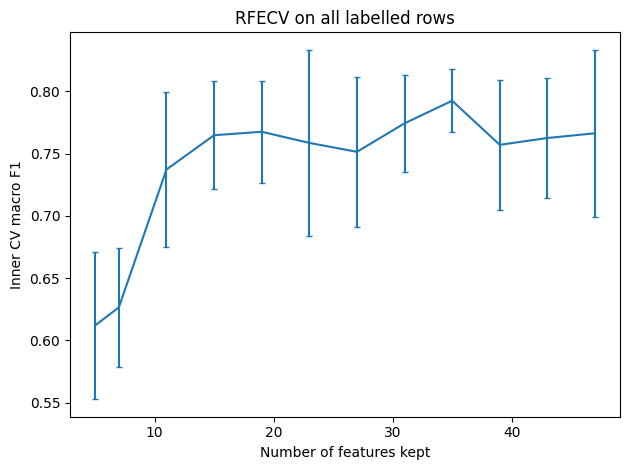

In [17]:
# Which features RFECV keeps when run on all 330 labelled rows
rfecv_full = make_rfecv().fit(X_all, y_all)

print("Optimal number of features:", rfecv_full.n_features_, "of", X_all.shape[1])
print("Selected features:", X_all.columns[rfecv_full.support_].tolist())
print("Dropped features:", X_all.columns[~rfecv_full.support_].tolist())

n_features_tried = np.arange(rfecv_full.min_features_to_select, X_all.shape[1] + 1)
plt.errorbar(rfecv_full.cv_results_['n_features'],
             rfecv_full.cv_results_['mean_test_score'],
             yerr=rfecv_full.cv_results_['std_test_score'], capsize=2)
plt.xlabel("Number of features kept")
plt.ylabel("Inner CV macro F1")
plt.title("RFECV on all labelled rows")
plt.tight_layout()
plt.show()

## Refit on all labelled data and write the Task 1 submission

In [18]:
# Refit the chosen model (including its RFECV step, if it has one) on all
# train + validation rows and predict the test set
best_model.fit(X_all, y_all)
test_predictions = best_model.predict(X_test)

submission = pd.DataFrame({'flow_id': test_features['flow_id'], 'app': test_predictions})
submission.to_csv('task1_static.csv', index=False)

print(submission['app'].value_counts())
submission.head()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

app
google       40
x            21
youtube      10
mozilla       7
instagram     2
facebook      1
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,flow_id,app
0,flow_000007,google
1,flow_000026,x
2,flow_000037,x
3,flow_000089,youtube
4,flow_000095,youtube
